In this notebook we are going to:

- solve a linear parameter identification problem with ordinary least squares (OLS) and prediction error method (PEM),
- compare their prediction / simulation performance for different prediction lengths.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

rng = np.random.default_rng(14588)

We again consider our toy example $x[k+1] = ax[k] + bu[k]$ for illustration.

In [2]:
Delta_t = 1.0  # time step width in s
Vs = 1.0  # steady-state gain
tau = 15.0  # time constant in s

a = 1.0 - Delta_t / tau
b = Vs * Delta_t / tau

N = 1000
u = np.zeros(N)
u[0:250] = 1.0
u[250:500] = -1.0
u[500:750] = 1.0
u[750:1000] = -1.0

x = np.zeros(N)
for k in range(1, N):
    x[k] = a * x[k-1] + b * u[k-1]

sigma = 0.1
y = x + sigma * rng.normal(size=N)

First, we find the usual OLS solution.

In [3]:
Y_OLS = y[1:]
Z_OLS = np.column_stack((y[:-1], u[:-1]))
w_OLS, *_ = np.linalg.lstsq(Z_OLS, Y_OLS, rcond=None)

Next, we find the PEM solution by minimizing the sum of squared prediction errors over the full trajectory.

In [4]:
def costs(w, u, y):
    N = len(u)
    x_sim = np.zeros(N)
    for k in range(1, N):
        x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1]
    return np.sum((y - x_sim) ** 2)

res = optimize.minimize(lambda w: costs(w, u, y), x0=np.array([0.0, 0.0]), method='BFGS')
w_PEM = res.x

C:\Users\27abd\AppData\Local\Temp\ipykernel_6512\2532827608.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1]
C:\Users\27abd\AppData\Local\Temp\ipykernel_6512\2532827608.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((y - x_sim) ** 2)
C:\Users\27abd\AppData\Roaming\Python\Python312\site-packages\scipy\optimize\_numdiff.py:686: RuntimeWarning: invalid value encountered in subtract
  df = [f_eval - f0 for f_eval in f_evals]
C:\Users\27abd\AppData\Local\Temp\ipykernel_6512\2532827608.py:5: RuntimeWarning: overflow encountered in scalar multiply
  x_sim[k] = w[0] * x_sim[k-1] + w[1] * u[k-1]
C:\Users\27abd\AppData\Local\Temp\ipykernel_6512\2532827608.py:6: RuntimeWarning: overflow encountered in square
  return np.sum((y - x_sim) ** 2)


To compare the identification results, we define a receding-horizon prediction cost over N_p steps.

In [5]:
def predict_error_costs(w, u, y, Np):
    N = len(u)
    total_cost = 0.0
    for k in range(0, N - 1, Np):
        if k + Np >= N:
            break
        x_pred = np.empty(Np + 1)
        x_pred[0] = y[k]
        for ii in range(1, Np + 1):
            x_pred[ii] = w[0] * x_pred[ii-1] + w[1] * u[k + ii - 1]
        total_cost += np.sum((y[k+1:k+Np+1] - x_pred[1:]) ** 2)
    return total_cost

Np_vec = np.arange(1, 101)
costs_PEM = np.zeros_like(Np_vec, dtype=float)
costs_OLS = np.zeros_like(Np_vec, dtype=float)
for idx, Np in enumerate(Np_vec):
    costs_PEM[idx] = predict_error_costs(w_PEM, u, y, Np)
    costs_OLS[idx] = predict_error_costs(w_OLS, u, y, Np)

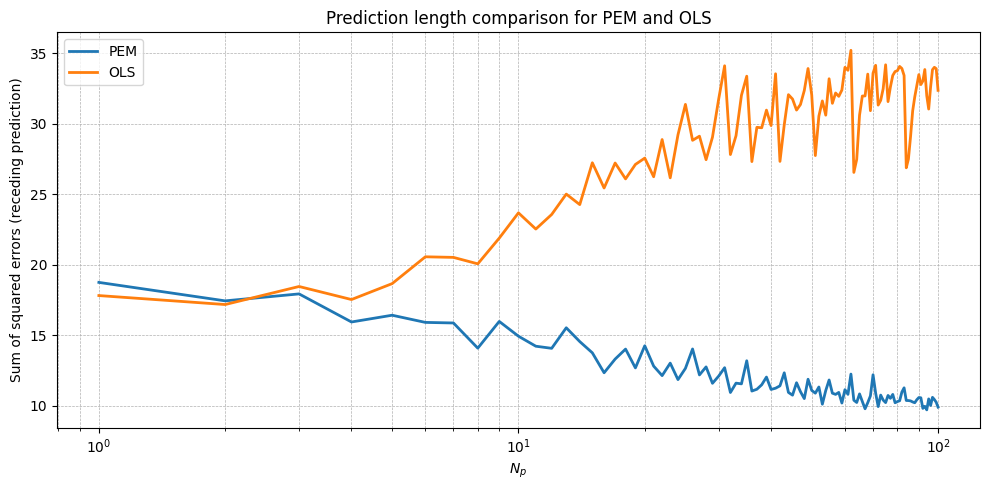

In [6]:
plt.figure(figsize=(10, 5))
plt.plot(Np_vec, costs_PEM, label='PEM', linewidth=2)
plt.plot(Np_vec, costs_OLS, label='OLS', linewidth=2)
plt.xscale('log')
plt.xlabel('$N_p$')
plt.ylabel('Sum of squared errors (receding prediction)')
plt.title('Prediction length comparison for PEM and OLS')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()